<a href="https://colab.research.google.com/github/pritrakholiya2512-pixel/EDUNET_GTU/blob/main/day7-13-07-2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving green_energy_dataset.csv to green_energy_dataset.csv
Dataset Loaded Successfully!
   Building_ID  Solar_kWh  Electricity_kWh  Water_Usage_Liters  Waste_kg  \
0            1        120              250                 450        18   
1            2        150              220                 400        15   
2            3         80              380                 620        28   
3            4        200              180                 350        12   
4            5         95              340                 580        25   

   Carbon_Emission_kg  
0                  90  
1                  80  
2                 140  
3                  65  
4                 130  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Building_ID         50 non-null     int64
 1   Solar_kWh           50 non-null     int64
 2   Electricity_kWh

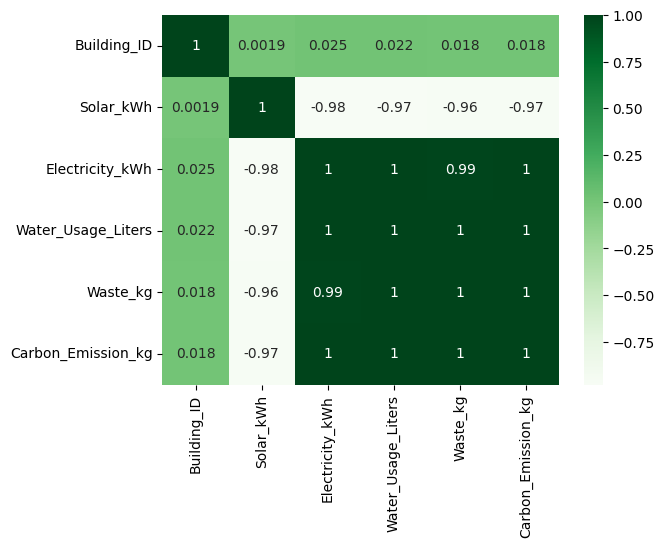

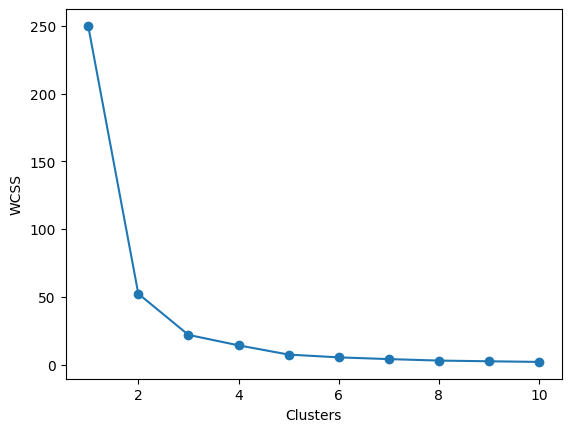

Cluster
1    18
0    17
2    15
Name: count, dtype: int64
Silhouette Score: 0.6080816001454347


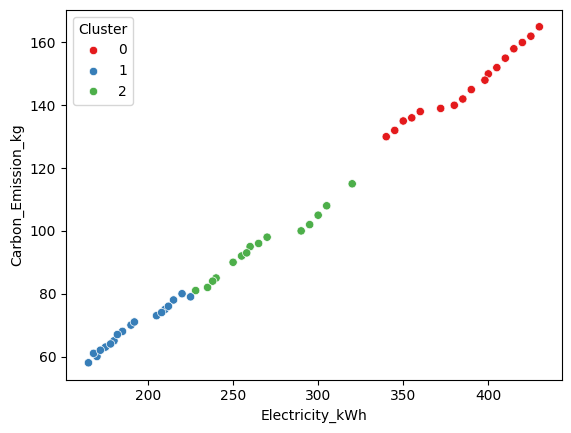

         Building_ID   Solar_kWh  Electricity_kWh  Water_Usage_Liters  \
Cluster                                                                 
0          25.764706   75.000000       387.058824          641.764706   
1          25.277778  185.166667       191.777778          366.555556   
2          25.466667  126.400000       267.266667          463.866667   

          Waste_kg  Carbon_Emission_kg  
Cluster                                 
0        30.588235          146.294118  
1        12.611111           69.111111  
2        18.133333           95.066667  


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from google.colab import files
uploaded = files.upload()
df=pd.read_csv('green_energy_dataset.csv')
print("Dataset Loaded Successfully!")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Greens')
plt.show()

X=df.drop('Building_ID',axis=1)
X=StandardScaler().fit_transform(X)

wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42,n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

km=KMeans(n_clusters=3,random_state=42,n_init=10)
df['Cluster']=km.fit_predict(X)
print(df['Cluster'].value_counts())
print('Silhouette Score:',silhouette_score(X,df['Cluster']))

sns.scatterplot(data=df,x='Electricity_kWh',y='Carbon_Emission_kg',hue='Cluster',palette='Set1')
plt.show()

df.to_csv('Clustered_Green_Energy_Dataset.csv',index=False)
print(df.groupby('Cluster').mean(numeric_only=True))
